In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from psyduck import Spin
from psyduck.operations import *

# spin-1/2 in a periodically modulated magnetic field. 

The lab frame Hamiltonian is: 

$H_{lab}(t)=2 \omega_0 \sigma_z+2\delta\omega\cos(\omega_m t)\sigma_x+\Omega\cos(\omega_d t)\sigma_x$

In the rotating frame at the drive frequency, the Hamiltonian is:

$H_{rot}​(t)=\frac{\Delta}{2} \sigma_z​+ \frac{\Omega}{2} ​\sigma_x​+ \frac{\delta \omega}{2} cos(\omega_m​ t)\sigma_x$

In [2]:
I = 7/2
H_quad = np.load(r'../quadrupole modeling/H_quad_fit.npy')
H = zeeman_hamiltonian(I, 1.4e9, gamma=1) + qt.Qobj(H_quad)

In [289]:
import numpy as np
import qutip as qt

# Parameters (angular frequencies)
omega0 = 1e6       # Larmor frequency (rad/s)
omega_d = omega0               # Drive frequency (on resonance)
Omega   = 100e3    # Rabi frequency (rad/s)

Delta = 6e6

# Longitudinal modulation parameters
delta_omega = 4e6  # modulation amplitude (rad/s)
omega_m     = 10e4 # modulation frequency (rad/s)

# Pauli operators
sx = qt.sigmax()
sz = qt.sigmaz()

# Time-dependent modulation function
def z_modulation(t, args):
    return np.cos(args['omega_m'] * t)

# Rotating-frame Hamiltonian with longitudinal modulation
H_rot = [
    0.5 * Delta * sz,
    [0.5 * delta_omega * sx, z_modulation]
]

# Initial state: |↑z>
psi0 = (qt.basis(2, 0) + qt.basis(2, 1)) / np.sqrt(2)

# Time grid
tlist = np.linspace(0, 50e-6, 2000)

# Solve Schrödinger equation
args = {'omega_m': omega_m}
result = qt.sesolve(H_rot, psi0, tlist, args=args)

# Observables
P_up = qt.expect(sx, result.states)

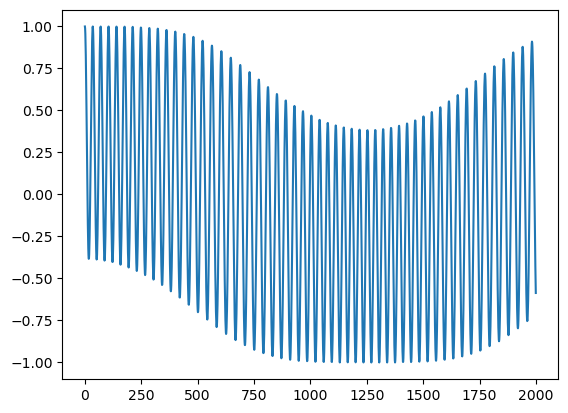

In [290]:
plt.plot(P_up)

In [291]:
# average over phases

In [294]:
import numpy as np
import qutip as qt


# Parameters (angular frequencies)
omega0 = 1e6       # Larmor frequency (rad/s)
omega_d = omega0               # Drive frequency (on resonance)
Omega   = 100e3    # Rabi frequency (rad/s)

Delta = 6e6

# Longitudinal modulation parameters
delta_omega = 4e6  # modulation amplitude (rad/s)
omega_m     = 10e4 # modulation frequency (rad/s)

# Pauli operators
sx = qt.sigmax()
sz = qt.sigmaz()

# Time grid
tlist = np.linspace(0, 50e-6, 2000)

# Initial state
psi0 = (qt.basis(2, 0) + qt.basis(2, 1)).unit()

# Number of phase realizations
N_realizations = 2

# Storage for averaged observable
sx_avg = np.zeros(len(tlist))

# Loop over random phases
for _ in range(N_realizations):

    phi = 2 * np.pi * np.random.rand()

    def z_modulation(t, args):
        return np.cos(args['omega_m'] * t + args['phi'])

    # Hamiltonian
    H_rot = [
        0.5 * Delta * sz,
        [0.5 * delta_omega * sx, z_modulation]
    ]

    args = {'omega_m': omega_m, 'phi': phi}

    result = qt.sesolve(H_rot, psi0, tlist, args=args)

    # Accumulate expectation value
    sx_avg += qt.expect(sx, result.states)

# Average
sx_avg /= N_realizations

Text(0, 0.5, 'Average <σx>')

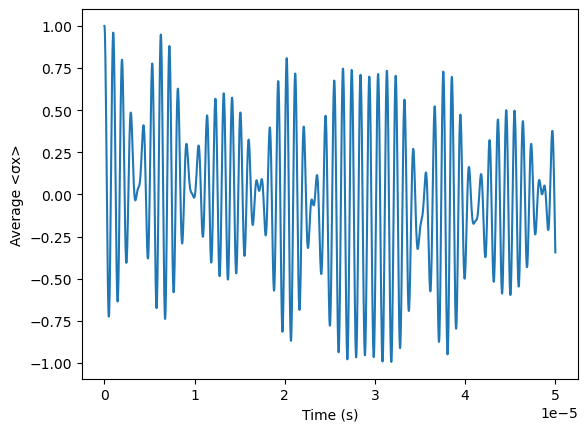

In [295]:
plt.plot(tlist, sx_avg)
plt.xlabel('Time (s)')
plt.ylabel('Average <σx>')
